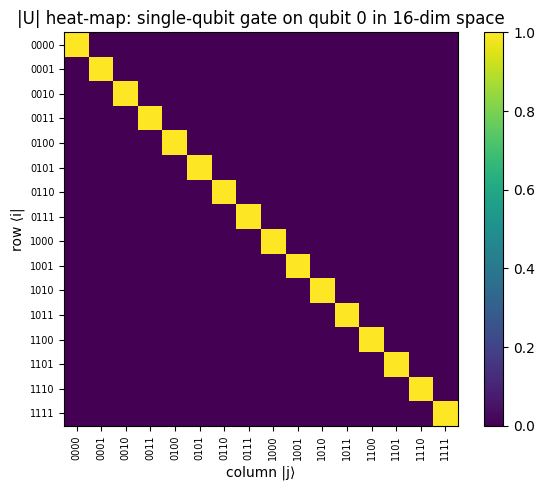

In [5]:
"""
Heat-map of a single-qubit gate embedded in an n-qubit Hilbert space (dimension 2**n).
Change `n`, `target`, and `gate` to suit your needs.
"""

import numpy as np
import matplotlib.pyplot as plt


# ----------------------------------------------------------------------
# Utility: embed a 2×2 gate acting on `target` (0 = LSB) into n qubits
def embed_single_qubit_gate(gate: np.ndarray, n: int, target: int) -> np.ndarray:
    """
    Kronecker-expand a single-qubit gate into the full 2**n × 2**n matrix.

    Parameters
    ----------
    gate   : 2×2 ndarray (complex)
        The single-qubit unitary.
    n      : int
        Total number of qubits (≥ 1).
    target : int
        Index of the qubit the gate acts on (0 = least-significant).

    Returns
    -------
    full_U : 2**n × 2**n ndarray (complex)
    """
    if not (0 <= target < n):
        raise ValueError("target qubit index must be between 0 and n-1")

    I = np.eye(2, dtype=complex)
    ops = [gate if k == target else I for k in range(n)]          # little-endian order
    full_U = ops[0]
    for op in ops[1:]:
        full_U = np.kron(full_U, op)
    return full_U


# ----------------------------------------------------------------------
# Plotting helper
def plot_single_qubit_gate(n: int,
                           target: int,
                           gate: np.ndarray,
                           cmap: str = "viridis") -> np.ndarray:
    """
    Draw |U| as a heat-map and return the embedded matrix.
    """
    U = embed_single_qubit_gate(gate, n, target)
    dim = 1 << n                      # 2**n

    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(np.abs(U), origin="upper", interpolation="nearest", cmap=cmap)

    # binary axis labels
    fmt = f"0{n}b"
    ax.set_xticks(range(dim))
    ax.set_yticks(range(dim))
    ax.set_xticklabels([format(j, fmt) for j in range(dim)], rotation=90, fontsize=7)
    ax.set_yticklabels([format(i, fmt) for i in range(dim)], fontsize=7)

    ax.set_xlabel("column |j⟩")
    ax.set_ylabel("row ⟨i|")
    ax.set_title(f"|U| heat-map: single-qubit gate on qubit {target} in {dim}-dim space")
    fig.colorbar(im, ax=ax, fraction=0.046)
    plt.tight_layout()
    plt.show()

    return U


# ----------------------------------------------------------------------
# Example ----------------------------------------------------------------
if __name__ == "__main__":
    n = 4            # total number of qubits
    target = 0       # act on qubit-1 (0 = LSB)
    X = np.array([[0, 1],
                  [1, 0]], dtype=complex)      # Pauli-X gate
    T = np.array([[1, 0],
                  [0, np.exp(1j * np.pi / 4)]], dtype=complex)  # T-gate
    U = plot_single_qubit_gate(n, target, T)


In [2]:
import torch

N, C, H, W = 2, 3, 4, 5
x = torch.arange(N * C * H * W).reshape(N, C, H, W)

print("Original shape  :", x.shape)

x1 = x.permute(0, 2, 1, 3)
print("After permute 1:", x1.shape)

x2 = x.permute(3, 0, 1, 2)
print("After permute 2:", x2.shape)


x_nhwc = x.permute(0, 2, 3, 1).contiguous()
print("NHWC shape     :", x_nhwc.shape)


Original shape  : torch.Size([2, 3, 4, 5])
After permute 1: torch.Size([2, 4, 3, 5])
After permute 2: torch.Size([5, 2, 3, 4])
NHWC shape     : torch.Size([2, 4, 5, 3])
